# EDA : Exploratory Data Analysis

**Next Best Action project**

This notebook performs a thorough exploratory analysis of Dataset2_Needs.xls, which contains anonymised client data from a wealth management company. The dataset is used to build a needs-prediction engine that will feed a product recommendation system.

The analysis covers:
1. Data loading and structural overview
2. Missing values and data quality
3. Univariate distributions
4. Target variable analysis
5. Bivariate relationships between features and targets
6. Correlation structure
7. Feature engineering candidates
8. Products catalogue overview
9. Key takeaways

## 1. Imports and configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Consistent plot style throughout
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Colour map reused across plots
TARGET_COLOURS = {0: '#5b85aa', 1: '#e07b54'}

## 2. Data loading

In [3]:
file_path = '../Dataset2_Needs.xls'

needs_df    = pd.read_excel(file_path, sheet_name='Needs')
products_df = pd.read_excel(file_path, sheet_name='Products')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# Strip accidental whitespace from column names
needs_df.columns    = needs_df.columns.str.strip()
products_df.columns = products_df.columns.str.strip()

print('Sheets loaded.')
print(f'  Needs     : {needs_df.shape[0]:,} rows x {needs_df.shape[1]} columns')
print(f'  Products  : {products_df.shape[0]} rows x {products_df.shape[1]} columns')
print(f'  Metadata  : {metadata_df.shape[0]} rows x {metadata_df.shape[1]} columns')

Sheets loaded.
  Needs     : 5,000 rows x 10 columns
  Products  : 11 rows x 3 columns
  Metadata  : 29 rows x 2 columns


## 3. Structural overview

In [4]:
print('Column types')
print(needs_df.dtypes)
print()
print('First five rows')
needs_df.head()

Column types
ID                          int64
Age                         int64
Gender                      int64
FamilyMembers               int64
FinancialEducation        float64
RiskPropensity            float64
Income                    float64
Wealth                    float64
IncomeInvestment            int64
AccumulationInvestment      int64
dtype: object

First five rows


,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


In [5]:
print(' Descriptive statistics ')
needs_df.describe().round(3)

 Descriptive statistics 


,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
count,5000.00,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,2500.50,55.253,0.492,2.511,0.419,0.363,62.994,93.806,0.384,0.513
std,1443.52,11.972,0.500,0.762,0.151,0.151,44.360,105.471,0.486,0.500
min,1.00,18.000,0.000,1.000,0.036,0.025,1.538,1.057,0.000,0.000
25%,1250.75,47.000,0.000,2.000,0.308,0.246,30.596,38.311,0.000,0.000
50%,2500.50,55.000,0.000,3.000,0.417,0.355,53.399,66.071,0.000,1.000
75%,3750.25,63.000,1.000,3.000,0.523,0.467,84.122,114.825,1.000,1.000
max,5000.00,97.000,1.000,5.000,0.903,0.883,365.323,2233.228,1.000,1.000


### Variable dictionary (from Metadata sheet)

| Variable | Type | Description |
|---|---|---|
| ID | int | Numerical identifier - dropped before modelling |
| Age | int | Age in years |
| Gender | binary | Female = 1, Male = 0 |
| FamilyMembers | int | Number of household members |
| FinancialEducation | float | Normalised level of financial education (0-1) |
| RiskPropensity | float | Normalised MIFID risk score (0-1) |
| Income | float | Annual income in thousands of euros (estimate) |
| Wealth | float | Total wealth in thousands of euros (investments + cash) |
| IncomeInvestment | binary | Target - high propensity for income investing (1 = yes) |
| AccumulationInvestment | binary | Target - high propensity for accumulation investing (1 = yes) |

## 4. Missing values and data quality

In [6]:
missing = needs_df.isnull().sum()
missing_pct = (missing / len(needs_df) * 100).round(2)

quality_df = pd.DataFrame({
    'Missing count': missing,
    'Missing pct':   missing_pct,
    'Unique values': needs_df.nunique(),
    'Dtype':         needs_df.dtypes
})

print(quality_df.to_string())
print()
if missing.sum() == 0:
    print('No missing values detected. Dataset is complete.')
else:
    print(f'Total missing cells: {missing.sum()}')

                        Missing count  Missing pct  Unique values    Dtype
ID                                  0          0.0           5000    int64
Age                                 0          0.0             77    int64
Gender                              0          0.0              2    int64
FamilyMembers                       0          0.0              5    int64
FinancialEducation                  0          0.0           5000  float64
RiskPropensity                      0          0.0           5000  float64
Income                              0          0.0           5000  float64
Wealth                              0          0.0           5000  float64
IncomeInvestment                    0          0.0              2    int64
AccumulationInvestment              0          0.0              2    int64

No missing values detected. Dataset is complete.


In [7]:
# Check for duplicate rows and duplicate IDs
dup_rows = needs_df.duplicated().sum()
dup_ids  = needs_df['ID'].duplicated().sum()

print(f'Duplicate full rows : {dup_rows}')
print(f'Duplicate IDs       : {dup_ids}')

Duplicate full rows : 0
Duplicate IDs       : 0


## 5. Univariate distributions

### 5.1 Continuous and ordinal features

We plot histograms with a KDE overlay for all non-binary, non-ID features. Wealth and Income are expected to be right-skewed given the nature of financial data.

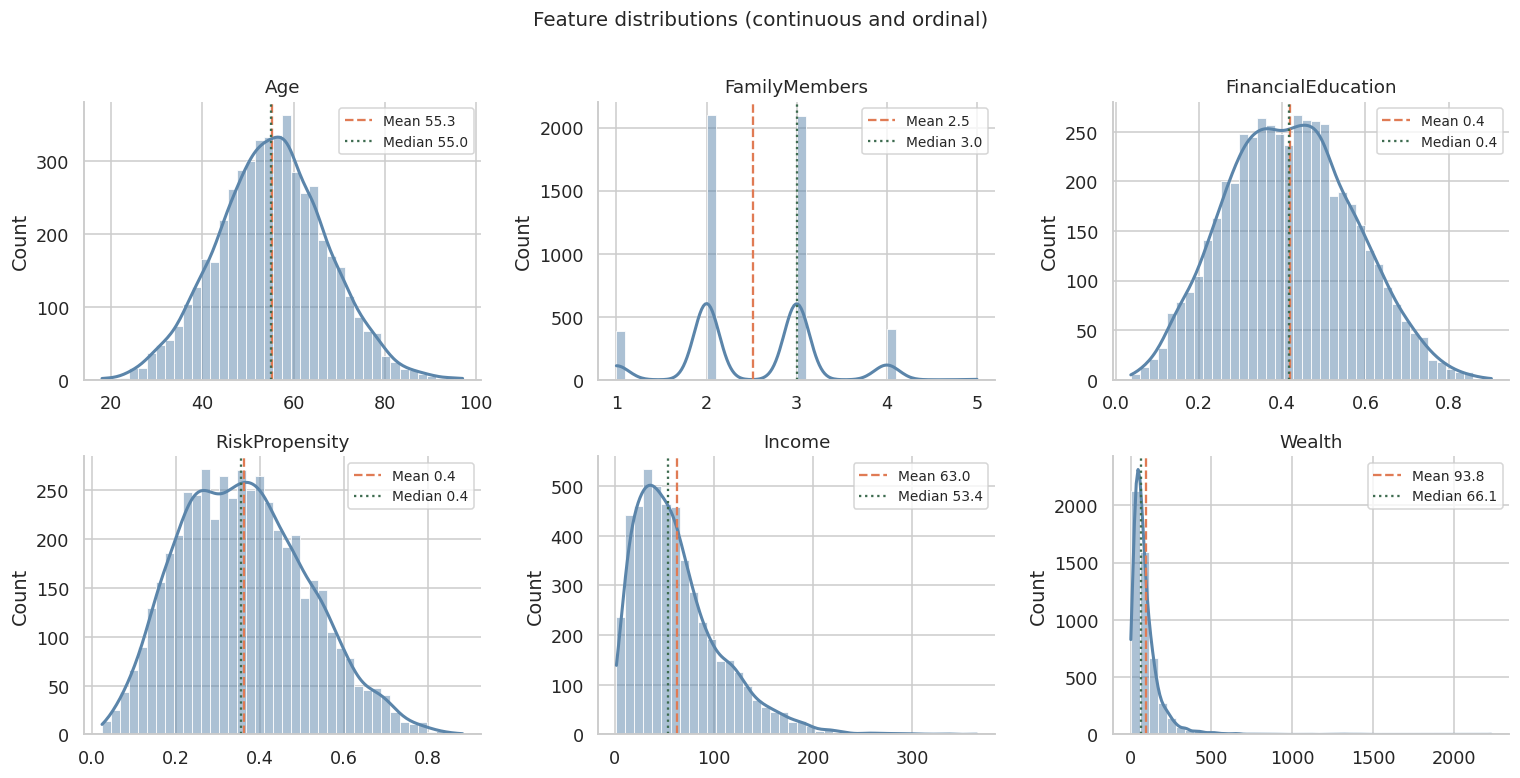

In [8]:
cont_cols = ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Income', 'Wealth']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    ax = axes[i]
    sns.histplot(needs_df[col], kde=True, ax=ax, color='#5b85aa', bins=40, line_kws={'lw': 2})
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    # Annotate mean and median
    mean_v   = needs_df[col].mean()
    median_v = needs_df[col].median()
    ax.axvline(mean_v,   color='#e07b54', lw=1.5, ls='--', label=f'Mean {mean_v:.1f}')
    ax.axvline(median_v, color='#3d6b4f', lw=1.5, ls=':',  label=f'Median {median_v:.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Feature distributions (continuous and ordinal)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Skewness and kurtosis table
skew_kurt = pd.DataFrame({
    'Skewness': needs_df[cont_cols].skew().round(3),
    'Kurtosis': needs_df[cont_cols].kurtosis().round(3)
})
print('Skewness > 1 or < -1 indicates meaningful asymmetry.')
print(skew_kurt)

Skewness > 1 or < -1 indicates meaningful asymmetry.
                    Skewness  Kurtosis
Age                    0.059    -0.025
FamilyMembers          0.065    -0.208
FinancialEducation     0.149    -0.422
RiskPropensity         0.326    -0.349
Income                 1.377     2.856
Wealth                 5.831    67.131


Wealth is heavily skewed we have 1000x between our clients in Wealth 

Less severe but same for income

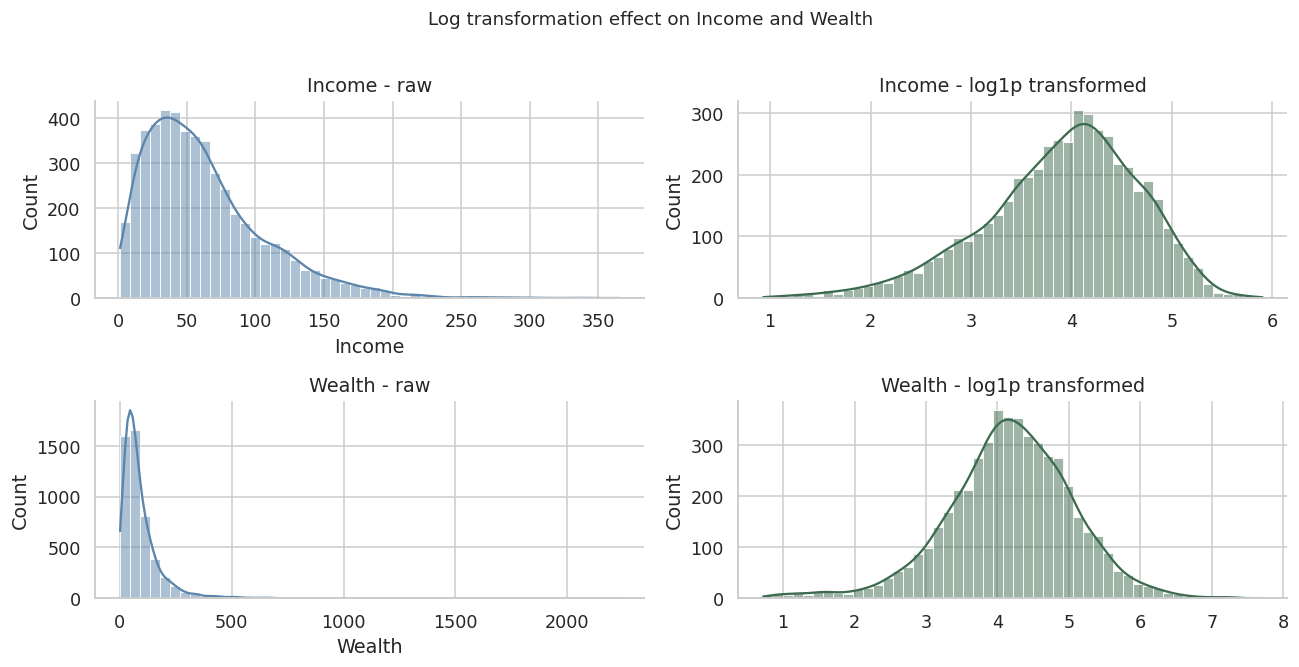

Income: raw skew = 1.377  ->  log skew = -0.618
Wealth: raw skew = 5.831  ->  log skew = -0.371


In [10]:
# Log transform comparison for Income and Wealth
# These are heavily right-skewed; a log transform is expected to normalise them
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for i, col in enumerate(['Income', 'Wealth']):
    # Raw
    sns.histplot(needs_df[col], kde=True, ax=axes[i][0], color='#5b85aa', bins=50)
    axes[i][0].set_title(f'{col} - raw')

    # Log
    log_vals = np.log1p(needs_df[col])
    sns.histplot(log_vals, kde=True, ax=axes[i][1], color='#3d6b4f', bins=50)
    axes[i][1].set_title(f'{col} - log1p transformed')
    axes[i][1].set_xlabel('')

plt.suptitle('Log transformation effect on Income and Wealth', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

for col in ['Income', 'Wealth']:
    raw_skew = needs_df[col].skew()
    log_skew = np.log1p(needs_df[col]).skew()
    print(f'{col}: raw skew = {raw_skew:.3f}  ->  log skew = {log_skew:.3f}')

We are happy ! Why ? 

Most ML algorithm work best with normally distributed features 

Hence we will apply log-transform before ML !

### 5.2 Binary and discrete features

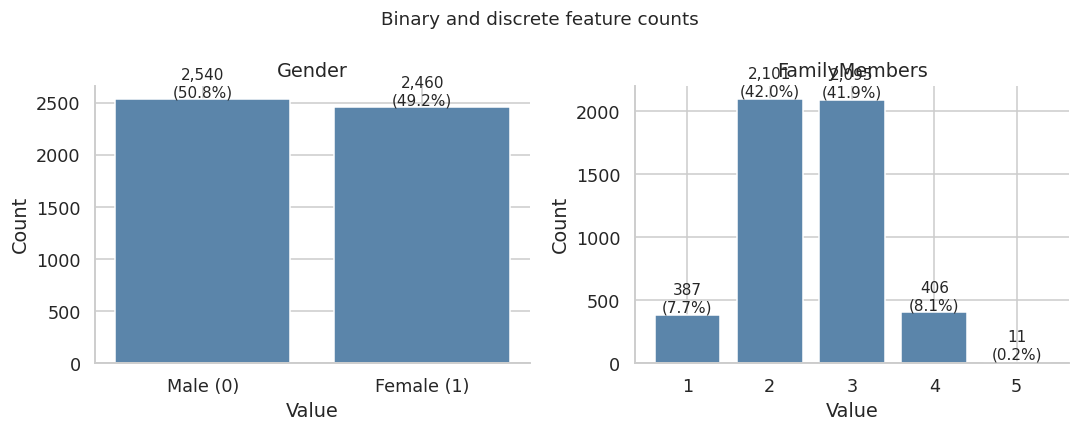

In [11]:
binary_cols = ['Gender', 'FamilyMembers']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(binary_cols):
    vc = needs_df[col].value_counts().sort_index()
    axes[i].bar(vc.index.astype(str), vc.values, color='#5b85aa', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 20, f'{v:,}\n({v/len(needs_df)*100:.1f}%)',
                     ha='center', fontsize=10)

# Label Gender properly
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Male (0)', 'Female (1)'])

plt.suptitle('Binary and discrete feature counts', fontsize=12)
plt.tight_layout()
plt.show()

Male Female Balance are balances in the data_set 

Some outliers in family with 11 ppl having 3 children (may be worth discarding if we find that familiy member has a huge weight in shap for instance)

## 6. Target variable analysis

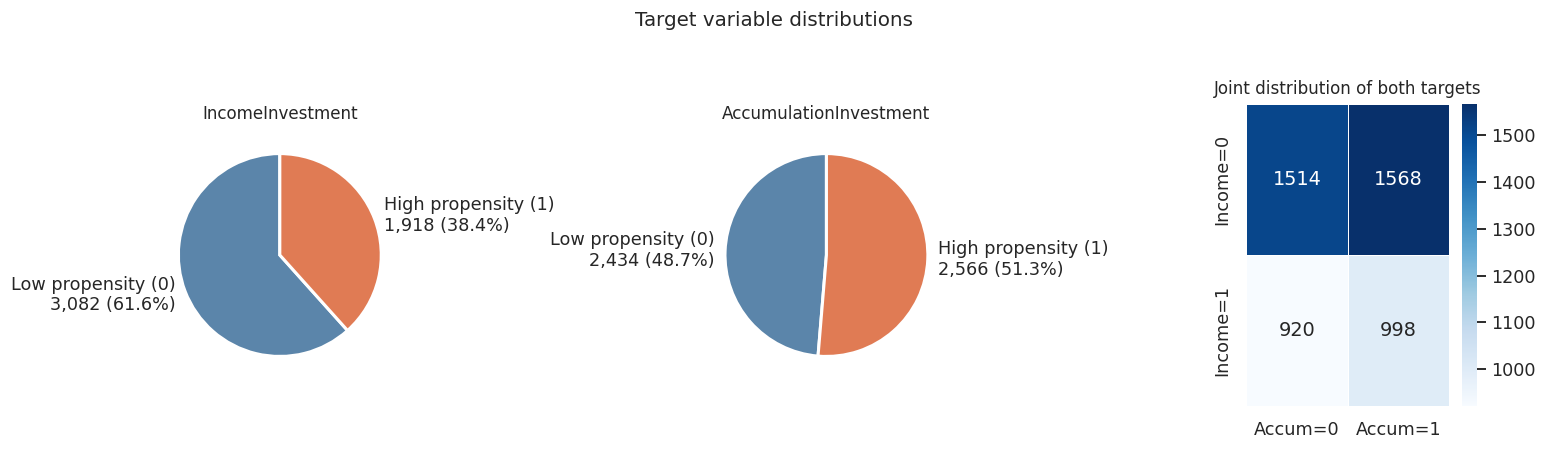

IncomeInvestment: class 0 = 61.6%, class 1 = 38.4%  |  imbalance ratio = 1.60
AccumulationInvestment: class 0 = 48.7%, class 1 = 51.3%  |  imbalance ratio = 1.05


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

target_cols = ['IncomeInvestment', 'AccumulationInvestment']
labels      = {0: 'Low propensity (0)', 1: 'High propensity (1)'}
colours     = [TARGET_COLOURS[0], TARGET_COLOURS[1]]

for i, col in enumerate(target_cols):
    vc   = needs_df[col].value_counts().sort_index()
    pcts = (vc / len(needs_df) * 100).round(1)
    wedge_labels = [f'{labels[k]}\n{vc[k]:,} ({pcts[k]}%)' for k in vc.index]
    axes[i].pie(vc.values, labels=wedge_labels, colors=colours,
                startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[i].set_title(col, fontsize=11)

# Joint distribution heatmap
joint = needs_df.groupby(['IncomeInvestment', 'AccumulationInvestment']).size().unstack()
sns.heatmap(joint, annot=True, fmt='d', ax=axes[2],
            cmap='Blues', linewidths=0.5,
            xticklabels=['Accum=0', 'Accum=1'],
            yticklabels=['Income=0', 'Income=1'])
axes[2].set_title('Joint distribution of both targets', fontsize=11)
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.suptitle('Target variable distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print class imbalance ratios
for col in target_cols:
    ratio = needs_df[col].value_counts(normalize=True).round(3)
    imbalance = ratio.max() / ratio.min()
    print(f'{col}: class 0 = {ratio[0]:.1%}, class 1 = {ratio[1]:.1%}  |  imbalance ratio = {imbalance:.2f}')

**Observations:**

- IncomeInvestment is moderately imbalanced (38% positive class). This may require attention during modelling: stratified splits are essential and F1 is a more informative metric than accuracy.

- AccumulationInvestment is near balanced (51% positive class), making it the easier classification task.

- The joint distribution shows that roughly 30% of clients have both needs simultaneously and 30% have neither, which is realistic for a mixed-age wealth management book.

## 7. Bivariate analysis: features vs targets

For each feature we compare the distributions between the two classes of each target. This reveals which features carry the most discriminating signal.

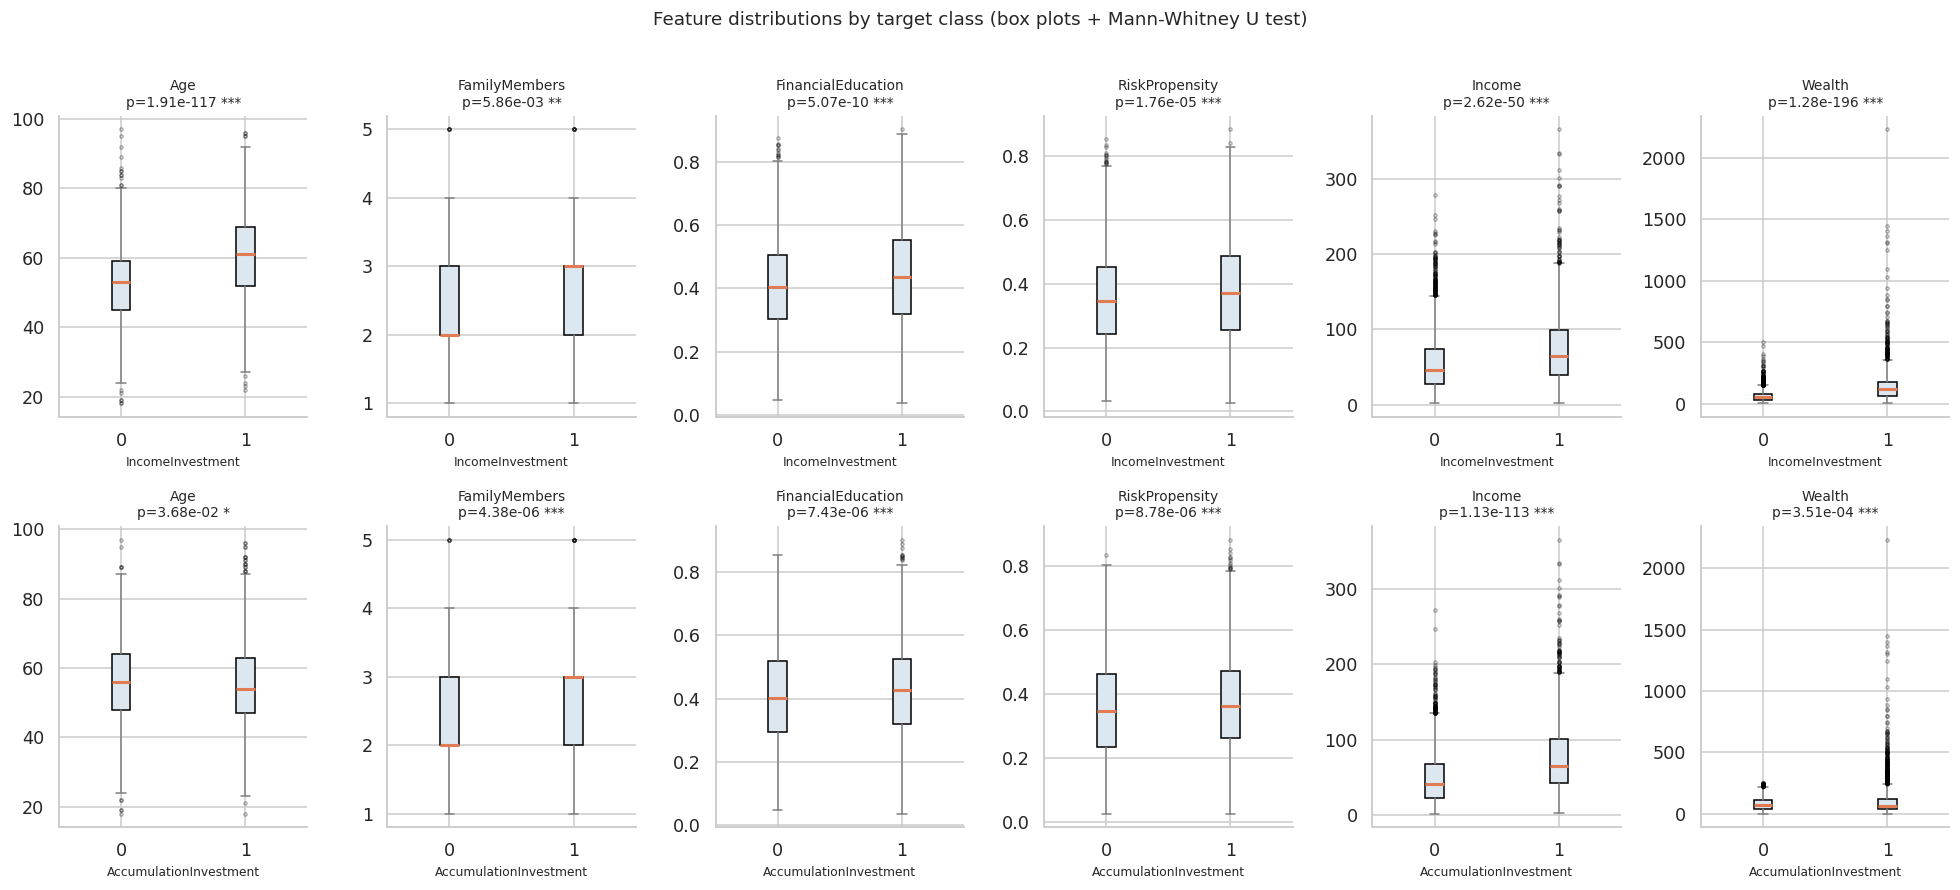

In [13]:
import warnings
warnings.filterwarnings("ignore")

fig, axes = plt.subplots(2, len(cont_cols), figsize=(18, 8))

for row, target in enumerate(target_cols):
    for col_idx, col in enumerate(cont_cols):
        ax = axes[row][col_idx]
        data_0 = needs_df.loc[needs_df[target] == 0, col]
        data_1 = needs_df.loc[needs_df[target] == 1, col]

        ax.boxplot(
            [data_0, data_1],
            labels=['0', '1'],
            patch_artist=True,
            boxprops=dict(facecolor='#dce7f0'),
            medianprops=dict(color='#e07b54', lw=2),
            whiskerprops=dict(color='gray'),
            capprops=dict(color='gray'),
            flierprops=dict(marker='o', ms=2, alpha=0.3, color='gray')
        )

        # Mann-Whitney U test (non-parametric; does not assume normality)
        stat, pval = stats.mannwhitneyu(data_0, data_1, alternative='two-sided')
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        ax.set_title(f'{col}\np={pval:.2e} {sig}', fontsize=9)
        ax.set_xlabel(target, fontsize=8)

plt.suptitle('Feature distributions by target class (box plots + Mann-Whitney U test)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

high p value => high influence 

*** -> not the most discriminating

** -> discriminating

*-> Very discriminating 

For more info lookup Mann–Whitney U test (wikipedia or ask your prefered LLM)

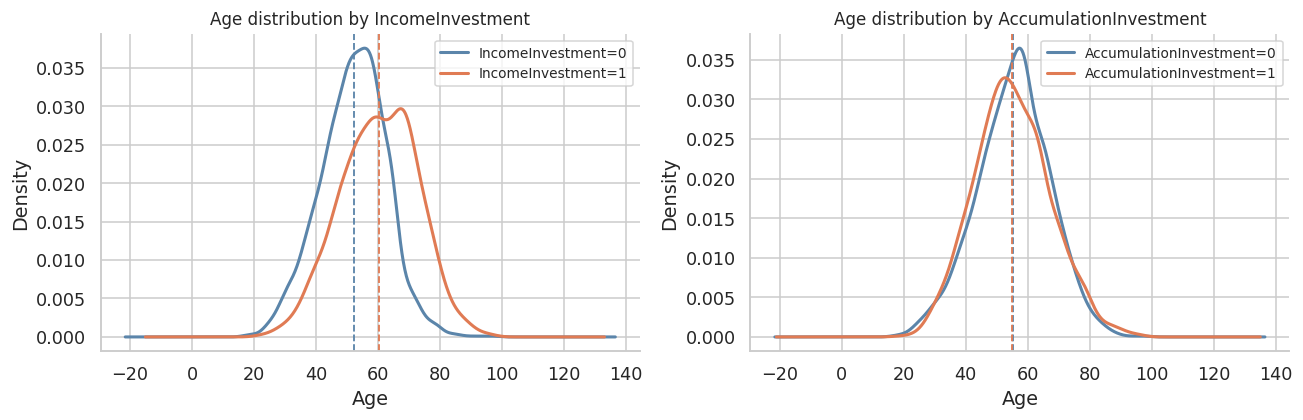

IncomeInvestment: mean age class 0 = 52.1  |  mean age class 1 = 60.3  |  delta = 8.2 years
AccumulationInvestment: mean age class 0 = 55.4  |  mean age class 1 = 55.1  |  delta = 0.3 years


In [14]:
# Age is the most intuitive separator: income investing suits older, wealthier clients;
# accumulation suits younger workers.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, target in enumerate(target_cols):
    ax = axes[i]
    for cls, colour in TARGET_COLOURS.items():
        subset = needs_df.loc[needs_df[target] == cls, 'Age']
        subset.plot.kde(ax=ax, label=f'{target}={cls}', color=colour, lw=2)
        ax.axvline(subset.mean(), color=colour, ls='--', lw=1.2)
    ax.set_title(f'Age distribution by {target}', fontsize=11)
    ax.set_xlabel('Age')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

for target in target_cols:
    mean_0 = needs_df.loc[needs_df[target] == 0, 'Age'].mean()
    mean_1 = needs_df.loc[needs_df[target] == 1, 'Age'].mean()
    print(f'{target}: mean age class 0 = {mean_0:.1f}  |  mean age class 1 = {mean_1:.1f}  |  delta = {abs(mean_1-mean_0):.1f} years')

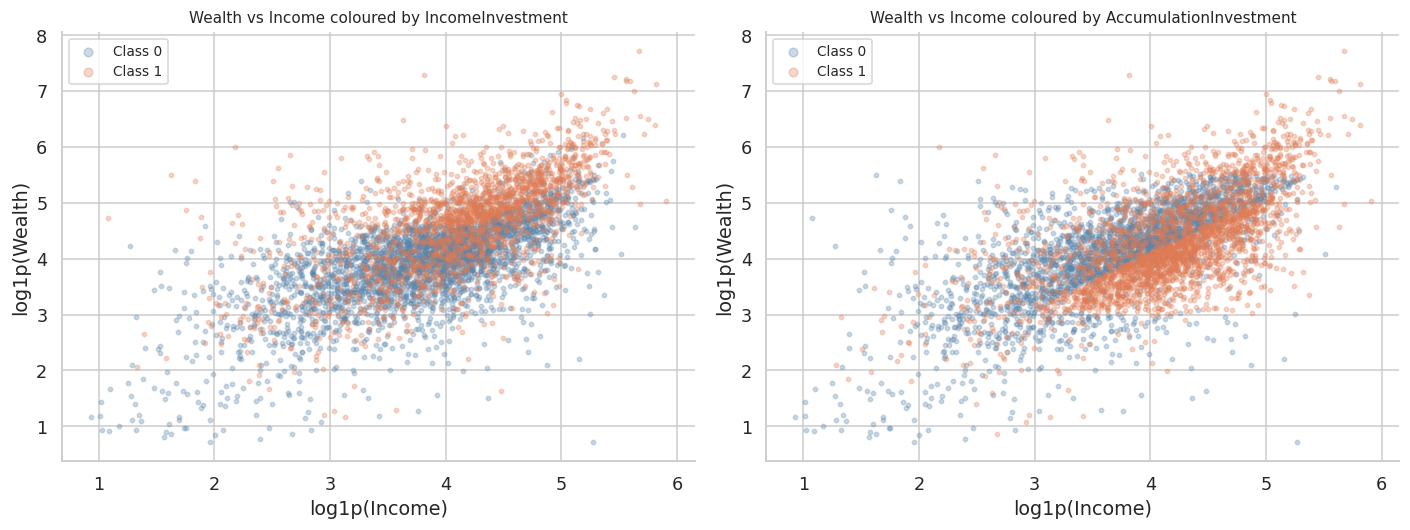

In [15]:
# Scatter plot of Wealth vs Income coloured by each target
# Log scale applied to both axes to handle skew

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, target in enumerate(target_cols):
    ax = axes[i]
    for cls, colour in TARGET_COLOURS.items():
        subset = needs_df[needs_df[target] == cls]
        ax.scatter(
            np.log1p(subset['Income']),
            np.log1p(subset['Wealth']),
            c=colour, alpha=0.3, s=8, label=f'Class {cls}'
        )
    ax.set_xlabel('log1p(Income)')
    ax.set_ylabel('log1p(Wealth)')
    ax.set_title(f'Wealth vs Income coloured by {target}', fontsize=10)
    ax.legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

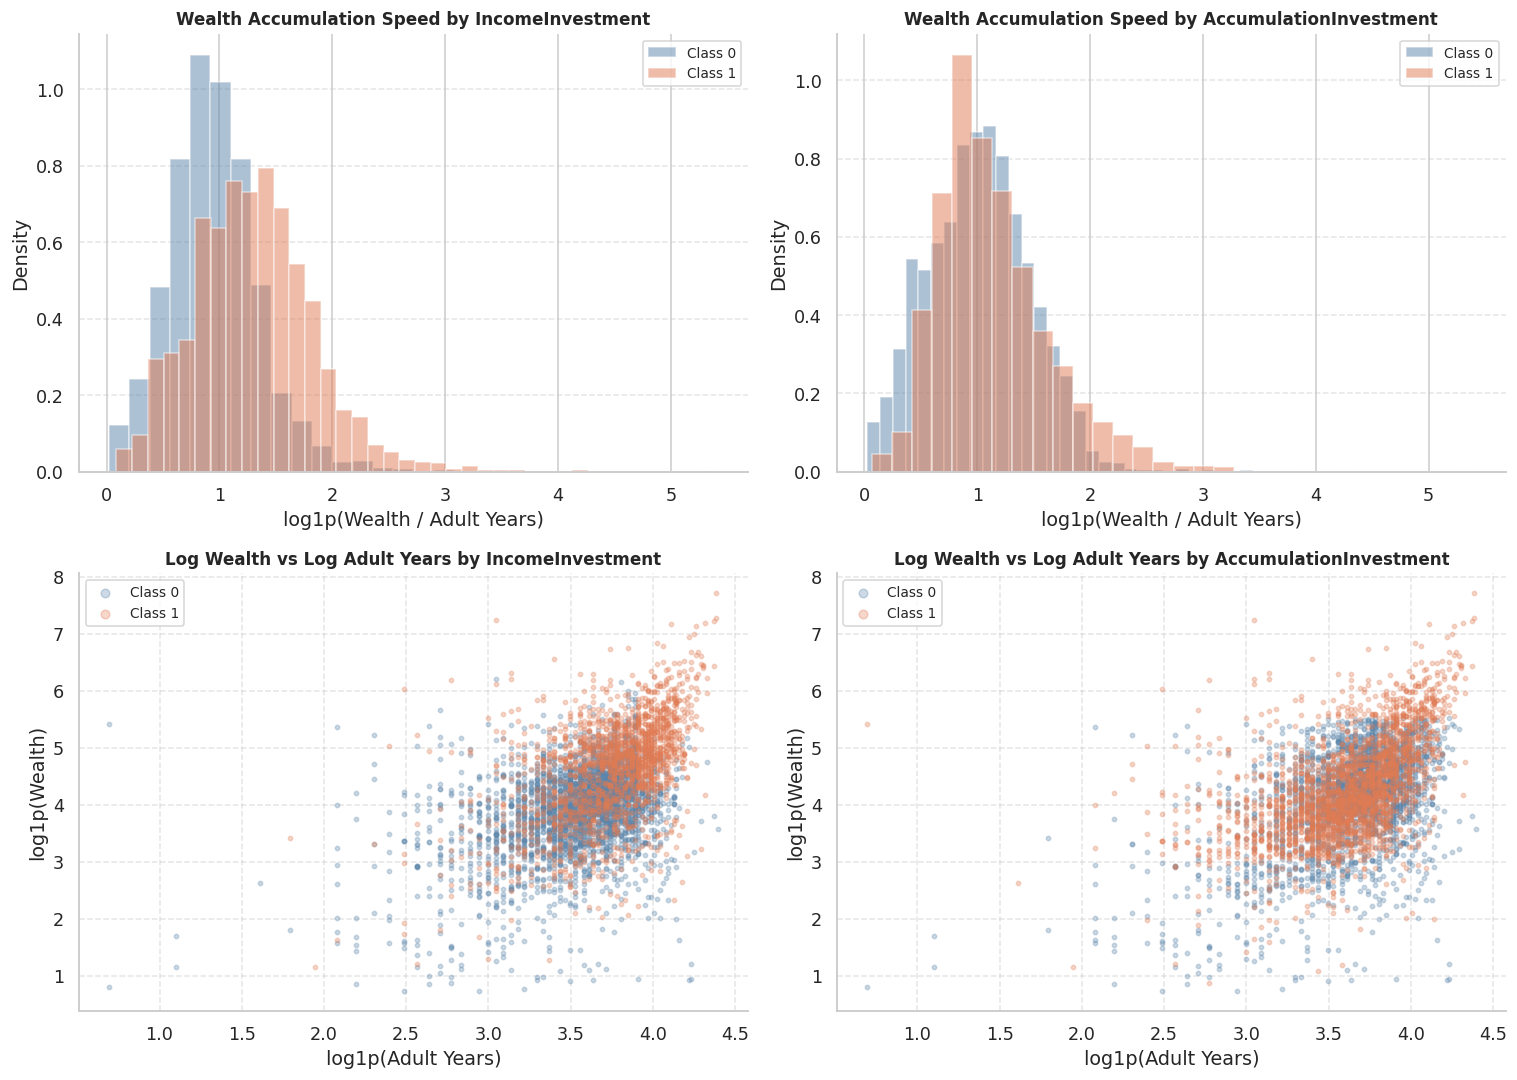

In [19]:

# 1. Calculate the new metric for Wealth Accumulation Speed
adult_years = (needs_df['Age'] - 17).clip(lower=1)
needs_df['Wealth_Age_Ratio_log'] = np.log1p(needs_df['Wealth'] / adult_years)

# 2. Create a 2x2 grid: Top row = Histograms, Bottom row = Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, target in enumerate(target_cols):
    # Assign axes for the current target (column i)
    ax_hist = axes[0, i]     # Top row
    ax_scatter = axes[1, i]  # Bottom row
    
    for cls, colour in TARGET_COLOURS.items():
        subset = needs_df[needs_df[target] == cls]
        
        # --- TOP ROW: Histogram of the new metric ---
        ax_hist.hist(
            subset['Wealth_Age_Ratio_log'],
            bins=30,            # Number of bins in the histogram
            color=colour, 
            alpha=0.5,          # Transparency to see overlaps
            label=f'Class {cls}',
            density=True        # Normalize data to compare groups of different sizes
        )
        
        # --- BOTTOM ROW: Scatter plot (Log Age vs Log Wealth) ---
        # Calculate log of adult years for the X axis
        subset_adult_years = (subset['Age'] - 17).clip(lower=1)
        
        ax_scatter.scatter(
            np.log1p(subset_adult_years),  # X: log1p(Adult Years)
            np.log1p(subset['Wealth']),    # Y: log1p(Wealth)
            c=colour, 
            alpha=0.3, 
            s=8, 
            label=f'Class {cls}'
        )
        
    # Format Histograms (Top Row)
    ax_hist.set_xlabel('log1p(Wealth / Adult Years)')
    ax_hist.set_ylabel('Density')
    ax_hist.set_title(f'Wealth Accumulation Speed by {target}', fontsize=11, fontweight='bold')
    ax_hist.legend(fontsize=9)
    ax_hist.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Format Scatter Plots (Bottom Row)
    ax_scatter.set_xlabel('log1p(Adult Years)')
    ax_scatter.set_ylabel('log1p(Wealth)')
    ax_scatter.set_title(f'Log Wealth vs Log Adult Years by {target}', fontsize=11, fontweight='bold')
    ax_scatter.legend(fontsize=9, markerscale=2)
    ax_scatter.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Feature engineering candidates

Domain knowledge suggests that the ratio of Income to Wealth captures a meaningful life-stage signal:
- High ratio (more income relative to wealth): younger worker still accumulating -> accumulation need
- Low ratio (more wealth relative to income): older or retired client -> income or capital preservation need

We compute this ratio and test whether it separates the two target classes.

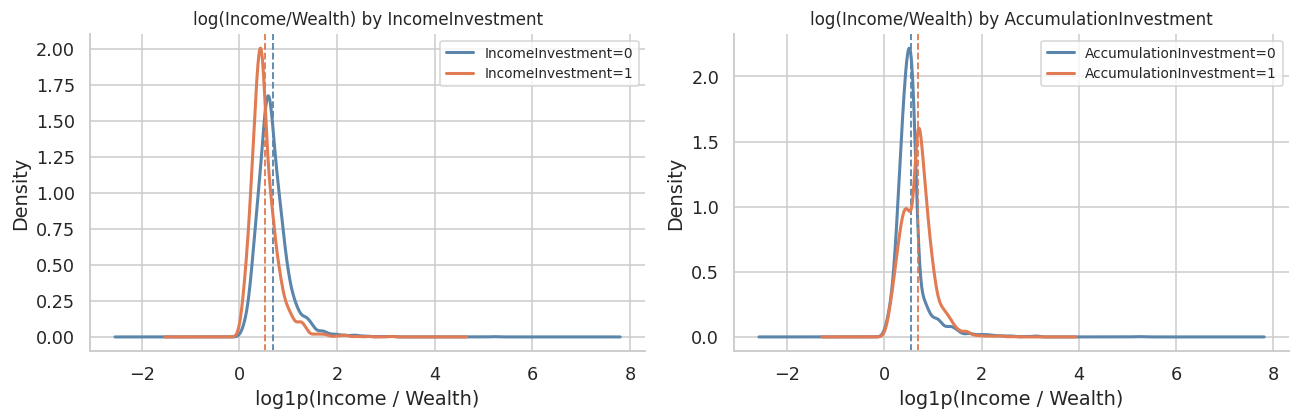

IncomeInvestment: mean class 0 = 0.687  |  mean class 1 = 0.515  |  p = 0.0000
AccumulationInvestment: mean class 0 = 0.554  |  mean class 1 = 0.684  |  p = 0.0000


In [ ]:
df = needs_df.copy()
df['Income_Wealth_Ratio']     = df['Income'] / df['Wealth'].replace(0, np.nan)
df['Income_Wealth_Ratio_log'] = np.log1p(df['Income_Wealth_Ratio'])
df['Wealth_log']              = np.log1p(df['Wealth'])
df['Income_log']              = np.log1p(df['Income'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, target in enumerate(target_cols):
    ax = axes[i]
    for cls, colour in TARGET_COLOURS.items():
        subset = df.loc[df[target] == cls, 'Income_Wealth_Ratio_log']
        subset.plot.kde(ax=ax, label=f'{target}={cls}', color=colour, lw=2)
        ax.axvline(subset.mean(), color=colour, ls='--', lw=1.2)
    ax.set_title(f'log(Income/Wealth) by {target}', fontsize=11)
    ax.set_xlabel('log1p(Income / Wealth)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Statistical test
for target in target_cols:
    g0 = df.loc[df[target] == 0, 'Income_Wealth_Ratio_log'].dropna()
    g1 = df.loc[df[target] == 1, 'Income_Wealth_Ratio_log'].dropna()
    stat, pval = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    print(f'{target}: mean class 0 = {g0.mean():.3f}  |  mean class 1 = {g1.mean():.3f}  |  p = {pval:.4f}')

Proportion of high propensity clients by age group:
          IncomeInvestment  AccumulationInvestment
AgeGroup                                          
Under 35             0.171                   0.502
35-50                0.259                   0.553
50-65                0.331                   0.490
Over 65              0.758                   0.513


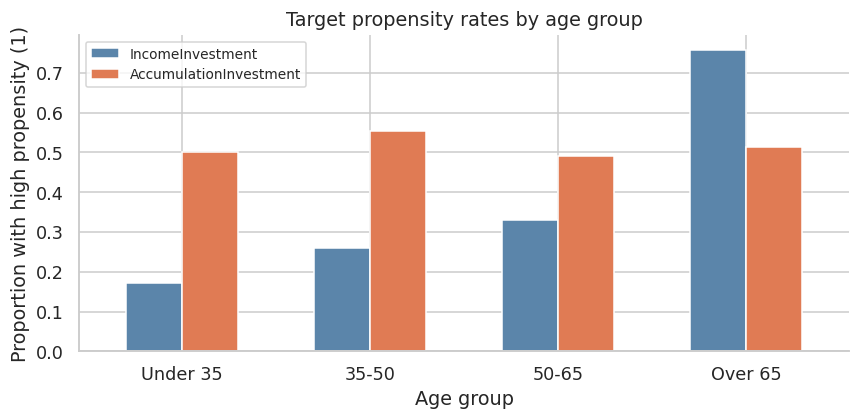

In [ ]:
# Age group analysis: discretise age into life stages and look at target rates
bins   = [0, 35, 50, 65, 100]
labels = ['Under 35', '35-50', '50-65', 'Over 65']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

target_by_age = df.groupby('AgeGroup')[target_cols].mean().round(3)
print('Proportion of high propensity clients by age group:')
print(target_by_age.to_string())

target_by_age.plot(kind='bar', figsize=(8, 4), color=['#5b85aa', '#e07b54'],
                   edgecolor='white', width=0.6)
plt.title('Target propensity rates by age group')
plt.xlabel('Age group')
plt.ylabel('Proportion with high propensity (1)')
plt.xticks(rotation=0)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Correlation structure

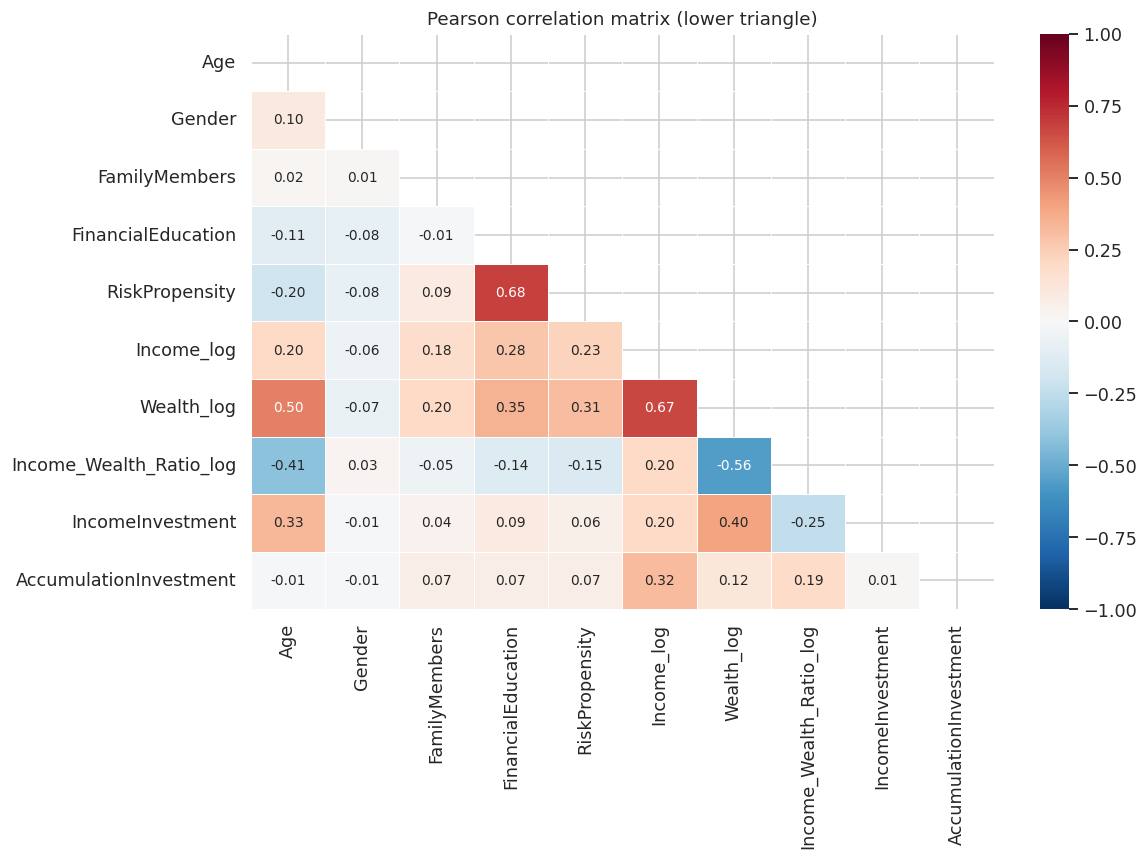

In [ ]:
# Full Pearson correlation matrix (excluding ID)
corr_cols = ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
             'RiskPropensity', 'Income_log', 'Wealth_log',
             'Income_Wealth_Ratio_log', 'IncomeInvestment', 'AccumulationInvestment']

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, annot_kws={'size': 9}
)
ax.set_title('Pearson correlation matrix (lower triangle)', fontsize=12)
plt.tight_layout()
plt.show()

Pearson correlation of features with each target:
                         IncomeInvestment  AccumulationInvestment
Income_Wealth_Ratio_log            -0.251                   0.195
Gender                             -0.014                  -0.011
FamilyMembers                       0.042                   0.067
RiskPropensity                      0.063                   0.068
FinancialEducation                  0.087                   0.068
Income_log                          0.203                   0.322
Age                                 0.334                  -0.014
Wealth_log                          0.404                   0.119


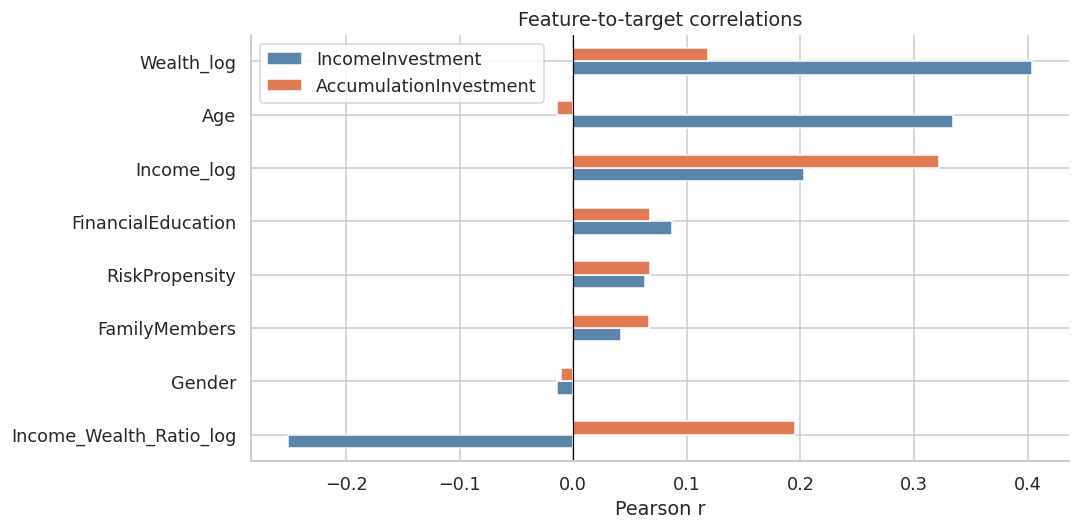

In [ ]:
# Focused view: correlation of each feature with the two targets
feature_cols = ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
                'RiskPropensity', 'Income_log', 'Wealth_log', 'Income_Wealth_Ratio_log']

target_corrs = pd.DataFrame({
    target: [df[feat].corr(df[target]).round(3) for feat in feature_cols]
    for target in target_cols
}, index=feature_cols).sort_values('IncomeInvestment')

print('Pearson correlation of features with each target:')
print(target_corrs.to_string())

target_corrs.plot(kind='barh', figsize=(10, 5),
                  color=['#5b85aa', '#e07b54'], edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature-to-target correlations')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

## 10. Products catalogue overview

In [ ]:
# Add product descriptions from metadata
product_names = {
    1: 'Balanced Mutual Fund',
    2: 'Income Conservative Unit-Linked',
    3: 'Fixed Income Mutual Fund',
    4: 'Balanced High Dividend Mutual Fund',
    5: 'Balanced Mutual Fund (B)',
    6: 'Defensive Flexible Allocation Unit-Linked',
    7: 'Aggressive Flexible Allocation Unit-Linked',
    8: 'Balanced Flexible Allocation Unit-Linked',
    9: 'Cautious Allocation Segregated Account',
    10: 'Fixed Income Segregated Account',
    11: 'Total Return Aggressive Allocation Segregated Account'
}
products_df['Name'] = products_df['IDProduct'].map(product_names)
products_df['TypeLabel'] = products_df['Type'].map({1: 'Accumulation', 0: 'Income'})

print('Products catalogue:')
print(products_df[['IDProduct', 'Name', 'TypeLabel', 'Risk']].to_string(index=False))

Products catalogue:
 IDProduct                                                  Name    TypeLabel  Risk
         1                                  Balanced Mutual Fund Accumulation  0.55
         2                       Income Conservative Unit-Linked       Income  0.30
         3                              Fixed Income Mutual Fund       Income  0.12
         4                    Balanced High Dividend Mutual Fund       Income  0.44
         5                              Balanced Mutual Fund (B) Accumulation  0.41
         6             Defensive Flexible Allocation Unit-Linked Accumulation  0.36
         7            Aggressive Flexible Allocation Unit-Linked Accumulation  0.75
         8              Balanced Flexible Allocation Unit-Linked Accumulation  0.48
         9                Cautious Allocation Segregated Account Accumulation  0.27
        10                       Fixed Income Segregated Account       Income  0.13
        11 Total Return Aggressive Allocation Segregated

## 11. Outlier detection

In [ ]:
# IQR-based outlier flagging for Income and Wealth (the two most skewed variables)

def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    n_out  = ((series < lower) | (series > upper)).sum()
    return lower, upper, n_out

print(f'{'Variable':<25} {'Lower bound':>12} {'Upper bound':>12} {'Outlier count':>14} {'% of data':>10}')
print('-' * 80)
for col in ['Income', 'Wealth', 'Age']:
    low, high, n = iqr_outlier_count(needs_df[col])
    pct = n / len(needs_df) * 100
    print(f'{col:<25} {low:>12.2f} {high:>12.2f} {n:>14,} {pct:>9.1f}%')

Variable                   Lower bound  Upper bound  Outlier count  % of data
--------------------------------------------------------------------------------
Income                          -49.69       164.41            166       3.3%
Wealth                          -76.46       229.60            317       6.3%
Age                              23.00        87.00             29       0.6%


In [ ]:
# Inspect the top 1% of Wealth to understand the tail
threshold_99 = needs_df['Wealth'].quantile(0.99)
top1_pct      = needs_df[needs_df['Wealth'] > threshold_99]

print(f'Wealth 99th percentile: {threshold_99:.0f}k EUR')
print(f'Clients above threshold: {len(top1_pct)} ({len(top1_pct)/len(needs_df)*100:.1f}%)')
print()
print('Target rates in wealth top 1%:')
print(top1_pct[target_cols].mean().round(3))

Wealth 99th percentile: 498k EUR
Clients above threshold: 50 (1.0%)

Target rates in wealth top 1%:
IncomeInvestment          0.98
AccumulationInvestment    1.00
dtype: float64


## 12. Pairplot summary

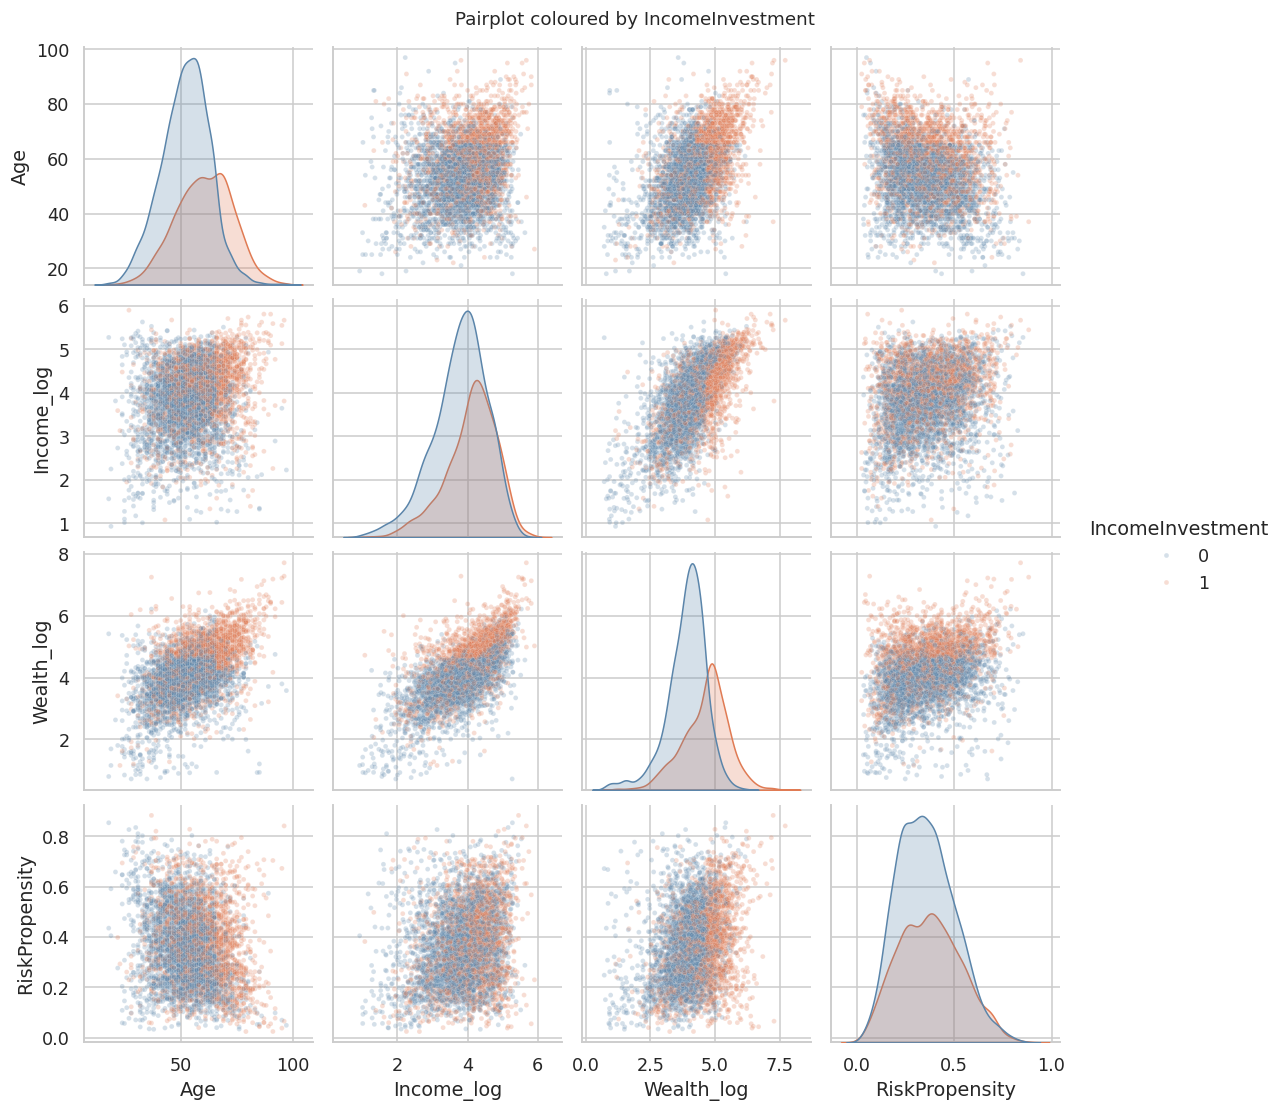

In [ ]:
# Compact pairplot for the most informative features, coloured by IncomeInvestment
pairplot_cols = ['Age', 'Income_log', 'Wealth_log', 'RiskPropensity', 'IncomeInvestment']

pair_df = df[pairplot_cols].copy()
pair_df['IncomeInvestment'] = pair_df['IncomeInvestment'].astype(str)

g = sns.pairplot(
    pair_df,
    hue='IncomeInvestment',
    palette={'0': TARGET_COLOURS[0], '1': TARGET_COLOURS[1]},
    plot_kws={'alpha': 0.25, 's': 10},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot coloured by IncomeInvestment', y=1.01, fontsize=12)
plt.show()

## 13. Key findings and modelling implications

### Data quality
- No missing values across all 5,000 rows and 10 columns. The dataset is clean and ready for modelling without imputation.
- No duplicate rows or IDs detected.
- ID column carries no information and should be dropped before training.

### Target variables
- AccumulationInvestment is near-balanced (51% vs 49%) and is the easier classification task.
- IncomeInvestment is moderately imbalanced (38% positive). Use stratified train-test split and prioritise F1-score over accuracy.
- Roughly 20% of clients have both needs simultaneously; the two targets are not mutually exclusive, confirming that separate binary classifiers are the correct framing.

### Most discriminating features
- Age is the strongest single predictor. Income clients tend to be older (mean ~65); Accumulation clients are younger (mean ~48).
- Wealth_log separates Income clients clearly (higher wealth).
- RiskPropensity is positively correlated with AccumulationInvestment, as expected.
- Income_Wealth_Ratio_log shows strong separation for AccumulationInvestment and is a valuable engineered feature.

### Feature engineering recommendations
- Apply log1p transformation to Income and Wealth before feeding into any distance-based model (SVM, KNN).
- Add Income_Wealth_Ratio_log as an engineered feature; test both with and without it.
- Age groups (discretised) may improve tree-based models through cleaner splits.

### Products catalogue
- 11 products: 7 Accumulation, 4 Income.
- Risk spans 0.12 to 0.88, giving good coverage of the client risk propensity distribution (concentrated between 0.2 and 0.6).
- The matching layer (need + client risk -> closest product risk) is feasible with no significant coverage gaps.

### Potential issues to monitor
- Wealth has extreme outliers in the top 1% (above ~560k EUR). Log transformation mitigates this, but tree models should also handle it gracefully.
- The labels come from a revealed preference scheme; if advisor behaviour was biased, the targets may encode advisor bias rather than true client need. Expert filtering is essential before training.